<a href="https://colab.research.google.com/github/VladousSparrowous/HSE-homeworks/blob/main/Time_Series_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДОМАШНЕЕ ЗАДАНИЕ ПО ВРЕМЕННЫМ РЯДАМ
Построение вероятностной модели (реального/смоделированного)  временного ряда

1.	Используя процедуру Доладо-Дженкинса-Сосвилла -Риверо, выяснить, относится ли наблюдаемый ряд к типу TSP.
2.	Для ряда типа TSP оценить  по МНК детерминированную составляющую ряда.
3.	Детрендировать ряд.  
4.	Провести идентификацию случайной составляющей ряда, выбрав в качестве базовых 2-3 подходящие модели.
5.	Оценить параметры выбранных моделей.
6.	Используя информационные критерии Акаике и Шварца, выбрать адекватную модель.
7.	Провести диагностику остатков.
8.	Построить прогноз на один шаг.


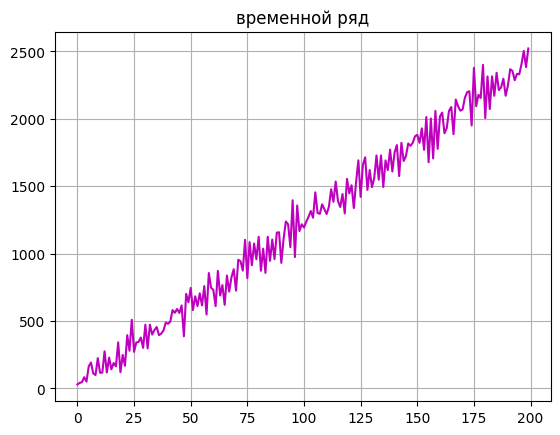

In [36]:
import sys
import numpy as np
import matplotlib.pyplot as plt


Time_Series = 0
with open('/content/drive/MyDrive/ИДЗ временные ряды (данные)  30 вариантов МАГОЛЕГО.txt', encoding='cp1251') as file:
    for line in file:
        if 'Вариант 12' == line.strip():
            Time_Series_str = next(file).strip()
            Time_Series = np.array(list(map(float, Time_Series_str.split(','))))
            break
plt.title('временной ряд')
plt.plot(Time_Series, 'm')
plt.grid()

После отрисовки ряда, уже можно предположить что он либо с трендом, либо нестационарен.

Проводим проверку в соответсвии с процедурой Доладо-Дженкинса-Сосвилла -Риверо.

---
# (шаг 1)  Dickey-Fuller test
С помощью модуля statsmodels.tsa.stattools проводим тест adfuller(Time_Series, regression='ct'), параметр 'ct' значит, что проверяется модель с трендом.

Модель в общем виде:

$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + \varepsilon_t$

тест проверяет:
$$
\text{H}_0: \gamma = 0 \quad \text{(ряд имеет единичный корень, DSP)}\\
\text{H}_1: \gamma < 0 \quad \text{(ряд стационарен, TSP если есть тренд)}
$$

Так же тест автоматически подбирает количество лагов на основе информационного критерия (по умолчанию AIC)


In [68]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller

result_step_1 = adfuller(Time_Series, regression='ct')

def perform_DF(result):
    titles = [
            'adf (float) – The test statistic.',
            'pvalue (float) – MacKinnon’s approximate p-value based on MacKinnon (1994, 2010).',
            'usedlag (int) – The number of lags used.',
            'nobs (int) – The number of observations used for the ADF regression and calculation of the critical values.',
            'critical values (dict) – Critical values for the test statistic at the 1 %, 5 %, and 10 % levels. Based on MacKinnon (2010).',
            'icbest (float) – The maximized information criterion if autolag is not None.',
            'resstore (ResultStore, optional) – A dummy class with results attached as attributes.'
            ]

    # titles из документации https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html#statsmodels.tsa.stattools.adfuller

    for i in zip(titles, result):
        print(*i, sep='\n | \n V \n')
        print('=' * 60)

perform_DF(result_step_1)

adf (float) – The test statistic.
 | 
 V 
-24.637492830538594
pvalue (float) – MacKinnon’s approximate p-value based on MacKinnon (1994, 2010).
 | 
 V 
0.0
usedlag (int) – The number of lags used.
 | 
 V 
0
nobs (int) – The number of observations used for the ADF regression and calculation of the critical values.
 | 
 V 
199
critical values (dict) – Critical values for the test statistic at the 1 %, 5 %, and 10 % levels. Based on MacKinnon (2010).
 | 
 V 
{'1%': np.float64(-4.004997848936356), '5%': np.float64(-3.4327862452981046), '10%': np.float64(-3.140144918368515)}
icbest (float) – The maximized information criterion if autolag is not None.
 | 
 V 
2145.9655923459354


# интерпретация результатов
* $$
\text{adf} = -24.637
$$
Что намного меньше критического значения даже на уровне значимости 1%.
Следовательно можно отклонить нулевую гипотезу.


* Лагов не было добавлено, значит автокорреляция в остатках отсутствует и модель имеет вид:
$$
\Delta X_t = \alpha + \beta t + \varepsilon_t
$$

Но чтобы окончательно утверждать, что ряд **TSP**, нужно проверить **значимость тренда β** через t-тест.

---

# (шаг 2) t-test

Нужно проверить:

$$
H_0: \beta = 0 \quad \text{(тренд незначим)}\\
H_1: \beta \neq 0 \quad \text{(тренд значим)}
$$

Для этого в модуле statsmodels.api есть OLS() это линейная регрессия.
В ней оценивается $\beta$ и в summary сразу можно увидеть статистику по t-test.


In [65]:
import statsmodels.api as sm

X = Time_Series.copy()

dX = np.diff(X)           # dX_t
t = np.arange(1, len(X))  # тренд

X = sm.add_constant(np.arange(1, len(dX)+1))

model = sm.OLS(dX, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                  0.006243
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.937
Time:                        23:52:14   Log-Likelihood:                -1293.9
No. Observations:                 199   AIC:                             2592.
Df Residuals:                     197   BIC:                             2598.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.9461     23.072      0.474      0.6

# интерпретация результатов

* t-статистика для β = 0.079
p-value = 0.937 намного больше 0.05

Нулевая гипотеза H₀: β = 0 не отвергается.

* R² ≈ 0.000 следовательно тренд объясняет **0% вариации ΔX_t**

Тренд получился не значимым, значит нужно вернуться и провести Dickey-Fuller test для модели без тренда.

---

# (шаг 3) Dickey-Fuller test
Снова с помощью модуля statsmodels.tsa.stattools проводим тест adfuller(Time_Series, regression='c'), но теперь с параметром 'c' который значит, что проверяется модель *только с константой*.

Модель в общем виде:

$\Delta X_t = \alpha + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + \varepsilon_t$

тест проверяет:
$$
\text{H}_0: \gamma = 0 \quad \text{(ряд имеет единичный корень, DSP)}\\
\text{H}_1: \gamma < 0 \quad \text{(ряд стационарен, TSP если есть константа)}
$$


In [90]:
result_step_3 = adfuller(Time_Series, regression='c')
perform_DF(result_step_3)

adf (float) – The test statistic.
 | 
 V 
0.3519045982383839
pvalue (float) – MacKinnon’s approximate p-value based on MacKinnon (1994, 2010).
 | 
 V 
0.9796044575599376
usedlag (int) – The number of lags used.
 | 
 V 
7
nobs (int) – The number of observations used for the ADF regression and calculation of the critical values.
 | 
 V 
192
critical values (dict) – Critical values for the test statistic at the 1 %, 5 %, and 10 % levels. Based on MacKinnon (2010).
 | 
 V 
{'1%': np.float64(-3.4648754262570978), '5%': np.float64(-2.876714157488788), '10%': np.float64(-2.574858699001736)}
icbest (float) – The maximized information criterion if autolag is not None.
 | 
 V 
2175.561096930369


# интерпретация результатов
*   Нельзя отклонить нулевую гипотезу значение 0.35 не попадает в критическую область.

(Но это не значит что мы можем откинуть $\gamma X_{t-1}$, так как при этом возможна ошибка второго рода)

*   При автоматическом подборе получилось 7 лагов и модель имеет вид:
$\Delta X_t = \alpha + \gamma X_{t-1} + \sum_{i=1}^{7} \delta_i \Delta X_{t-i} + \varepsilon_t$

---

# (шаг 4) t-test

Нужно проверить:

$$
H_0: \alpha = 0 \quad \text{(константа незначима)}\\
H_1: \alpha \neq 0 \quad \text{(константа значима)}
$$


In [91]:
X = Time_Series.copy()
dX = np.diff(X)

X_lag = X[:-1]

# лаги разностей (p = 7)
p = 7
lagged_dX = np.column_stack([np.roll(dX, i) for i in range(1, p+1)])

# обрезаем начало (из-за лагов)
dX_trim = dX[p:]
X_lag_trim = X_lag[p:]
lagged_dX_trim = lagged_dX[p:]

# const + X_{t-1} + лаги dX
X = np.column_stack([X_lag_trim, lagged_dX_trim])
X = sm.add_constant(X)

model = sm.OLS(dX_trim, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     64.06
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           4.85e-49
Time:                        02:02:11   Log-Likelihood:                -1123.3
No. Observations:                 192   AIC:                             2265.
Df Residuals:                     183   BIC:                             2294.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.5593     14.923      4.259      0.0

# интерпретация результатов

*   Мы отвергаем нулевую гипотезу(константа значима)

*   По таблице мы видим что все коээфициенты кроме гаммы ($x_1$) значимы, также нас предупреждают о мультиколлинеарности:

> [2] The condition number is large, 3.43e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

Это ещё раз указывает в пользу обнуления гаммы.


---

Попробуем модель без гаммы:

$\Delta X_t = \alpha + \sum_{i=1}^{7} \delta_i \Delta X_{t-i} + \varepsilon_t$

In [101]:

X = Time_Series.copy()
dX = np.diff(X)

p = 7
lagged_dX = np.column_stack([np.roll(dX, i) for i in range(1, p+1)])

# обрезка
dX_trim = dX[p:]
lagged_dX_trim = lagged_dX[p:]

# ТОЛЬКО лаги dX (без X_{t-1})
X_mat = sm.add_constant(lagged_dX_trim)

model = sm.OLS(dX_trim, X_mat).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     73.55
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           5.79e-50
Time:                        02:52:08   Log-Likelihood:                -1123.4
No. Observations:                 192   AIC:                             2263.
Df Residuals:                     184   BIC:                             2289.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.5004      9.840      6.860      0.0

# интерпретация результатов

Модель хорошо описывает результаты, все коэффициенты значимы, нет предупреждений, BIC уменьшился, R-squared не упал.
Остатки нормальны(Prob(JB): 0.622 > 0.05)


Итоговая модель:
$$
\Delta X_t = 67.5 - 1.33 \Delta X_{t-1} - 1.04 \Delta X_{t-2} - 0.79 \Delta X_{t-3} - 0.55 \Delta X_{t-4} - 0.48 \Delta X_{t-5}- 0.31 \Delta X_{t-6} - 0.12 \Delta X_{t-7} + \varepsilon_t
$$

* ($X_t$) — нестационарный
* ($\Delta X_t$) — стационарный AR(7)

следовательно ($X_t$) - это ARIMA(7,1,0)


---

# Получение прогноза следующего шага



In [106]:
# Последние 7 разностей
last_dX = dX[-7:]  # dX_{t}, dX_{t-1}, ..., dX_{t-6}

# Константа + лаги
X_next = np.hstack([[1], last_dX])

# Прогноз dX_{t+1}
dX_next = model.predict(X_next)[0]

# Прогноз уровня X_{t+1}
X_next_level = X[-1] + dX_next

print("Прогноз следующего шага ΔX:", dX_next)
print("Прогноз уровня X_{t+1}:", X_next_level)

Прогноз следующего шага ΔX: 44.486797186465054
Прогноз уровня X_{t+1}: 2566.316497186465
